# 🎙️ Multilingual Speech Emotion Recognition
## Notebook 1: Data Preprocessing & Feature Extraction

**Datasets:**
- RAVDESS (English) — `/kaggle/input/ravdess-emotional-speech-audio/`
- TESS (English) — `/kaggle/input/toronto-emotional-speech-set-tess/`
- EmoTa (Tamil) — `/kaggle/input/emota-tamil/`
- Sinhala 100 clips — `/kaggle/input/sinhala-emotion-audio/`

**Output:** Processed features + metadata saved to `/kaggle/working/processed/`

In [1]:
# ─── Install Dependencies ───────────────────────────────────────────────────
!pip install opensmile audiomentations librosa soundfile tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.8/137.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 21.4 MB/s eta 0:00:00


In [2]:
# ─── Imports ────────────────────────────────────────────────────────────────
import os
import re
import json
import shutil
import random
import warnings
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import opensmile
import audiomentations as A
from pathlib import Path
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

print('All imports OK')

All imports OK


In [3]:
# ─── Configuration ──────────────────────────────────────────────────────────
# !! UPDATE THESE PATHS TO MATCH YOUR KAGGLE DATASET NAMES !!
PATHS = {
    'ravdess':  '/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio',
    'tess':     '/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess',
    'emota':    '/kaggle/input/datasets/senadhithimanya/emo-ta',          # adjust to your dataset folder
    'sinhala':  '/kaggle/input/datasets/senadhithimanya/sinhala-labeled-100/data' # adjust to your dataset folder
}

OUTPUT_DIR = Path('/kaggle/working/processed')
AUDIO_DIR  = OUTPUT_DIR / 'augmented_audio'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
AUDIO_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_RATE = 16000   # Whisper and most models expect 16kHz
MAX_DURATION = 6.0    # seconds — clip or pad to this length

# ─── Unified Emotion Label Set ───────────────────────────────────────────────
# We map ALL datasets to these 5 core emotions
EMOTION_LABELS = ['neutral', 'happy', 'sad', 'angry', 'fear']
EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTION_LABELS)}
NUM_EMOTIONS   = len(EMOTION_LABELS)

print(f'Emotion classes ({NUM_EMOTIONS}):', EMOTION_LABELS)
print(f'Output directory: {OUTPUT_DIR}')

Emotion classes (5): ['neutral', 'happy', 'sad', 'angry', 'fear']
Output directory: /kaggle/working/processed


## 1. Dataset Loaders
Each loader returns a list of dicts: `{path, emotion, language, dataset}`

In [4]:
# ─── RAVDESS Loader ──────────────────────────────────────────────────────────
# Filename format: 03-01-[EMOTION]-01-01-01-01.wav
# Emotion codes: 01=neutral, 02=calm, 03=happy, 04=sad,
#                05=angry,   06=fearful, 07=disgust, 08=surprised
RAVDESS_EMOTION_MAP = {
    '01': 'neutral',
    '02': 'neutral',   # calm → neutral (closest match)
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fear',
    '07': None,
    '08': None         # surprised → drop (not in our label set)
}

def load_ravdess(base_path):
    records = []
    base = Path(base_path)
    # RAVDESS has Actor_01/ ... Actor_24/ subdirs
    for wav in base.rglob('*.wav'):
        parts = wav.stem.split('-')
        if len(parts) < 3:
            continue
        emotion_code = parts[2]
        emotion = RAVDESS_EMOTION_MAP.get(emotion_code)
        if emotion is None:
            continue  # skip 'surprised'
        records.append({
            'path':     str(wav),
            'emotion':  emotion,
            'language': 'english',
            'dataset':  'ravdess'
        })
    print(f'RAVDESS: {len(records)} clips loaded')
    return records


# ─── TESS Loader ─────────────────────────────────────────────────────────────
# Filename format: OAF_word_EMOTION.wav or YAF_word_EMOTION.wav
TESS_EMOTION_MAP = {
    'angry':    'angry',
    'disgust':  None,
    'fear':     'fear',
    'happy':    'happy',
    'ps':       'happy',   # pleasant surprise → happy
    'sad':      'sad',
    'neutral':  'neutral'
}

def load_tess(base_path):
    records = []
    base = Path(base_path)
    for wav in base.rglob('*.wav'):
        # Emotion is the last underscore-separated token before extension
        parts = wav.stem.lower().split('_')
        emotion_raw = parts[-1]
        emotion = TESS_EMOTION_MAP.get(emotion_raw)
        if emotion is None:
            continue
        records.append({
            'path':     str(wav),
            'emotion':  emotion,
            'language': 'english',
            'dataset':  'tess'
        })
    print(f'TESS: {len(records)} clips loaded')
    return records


# ─── EmoTa Loader (TamilSER-DB filename parsing) ─────────────────────────────
from pathlib import Path

EMOTA_EMOTION_MAP = {
    'ang': 'angry',
    'hap': 'happy',
    'sad': 'sad',
    'neu': 'neutral',
    'fea': 'fear'
}

def load_emota(base_path):
    records = []
    base = Path(base_path)

    for wav in base.rglob("*.wav"):

        # Example filename: 01_01_ang.wav
        name = wav.stem
        parts = name.split("_")

        if len(parts) < 3:
            continue

        emotion_code = parts[-1].lower()
        emotion = EMOTA_EMOTION_MAP.get(emotion_code)

        if emotion is None:
            continue

        records.append({
            "path": str(wav),
            "emotion": emotion,
            "language": "tamil",
            "dataset": "emota"
        })

    return records

    # ── Option B: Try CSV manifest ──
    if not found_via_folders:
        csv_candidates = list(base.glob('*.csv'))
        if csv_candidates:
            df = pd.read_csv(csv_candidates[0])
            # Adjust column names to match your CSV
            file_col    = [c for c in df.columns if 'file' in c.lower() or 'path' in c.lower()][0]
            emotion_col = [c for c in df.columns if 'emotion' in c.lower() or 'label' in c.lower()][0]
            for _, row in df.iterrows():
                emotion = EMOTA_EMOTION_MAP.get(str(row[emotion_col]).lower())
                if emotion is None:
                    continue
                records.append({
                    'path':     str(base / row[file_col]),
                    'emotion':  emotion,
                    'language': 'tamil',
                    'dataset':  'emota'
                })

    print(f'EmoTa: {len(records)} clips loaded')
    return records

#--Sinhala dataset loading
from pathlib import Path

SINHALA_EMOTION_MAP = {
    'neutral': 'neutral',
    'happy':   'happy',
    'happiness':   'happy',
    'sad':     'sad',
    'sadness':     'sad',
    'angry':   'angry',
    'anger': 'angry',
    'fear':    'fear'
}

def load_sinhala(base_path):
    records = []
    base = Path(base_path)

    for wav in base.rglob("*.wav"):

        # Emotion folder is the parent directory of the wav file
        emotion_folder = wav.parent.name.lower()

        emotion = SINHALA_EMOTION_MAP.get(emotion_folder)
        if emotion is None:
            continue

        records.append({
            "path": str(wav),
            "emotion": emotion,
            "language": "sinhala",
            "dataset": "sinhala"
        })

    return records

    # ── Option B: CSV manifest ──
    if not records:
        csv_candidates = list(base.glob('*.csv'))
        if csv_candidates:
            df = pd.read_csv(csv_candidates[0])
            file_col    = [c for c in df.columns if 'file' in c.lower() or 'path' in c.lower()][0]
            emotion_col = [c for c in df.columns if 'emotion' in c.lower() or 'label' in c.lower()][0]
            for _, row in df.iterrows():
                emotion = SINHALA_EMOTION_MAP.get(str(row[emotion_col]).lower())
                if emotion is None:
                    continue
                records.append({
                    'path':     str(base / row[file_col]),
                    'emotion':  emotion,
                    'language': 'sinhala',
                    'dataset':  'sinhala'
                })

    print(f'Sinhala: {len(records)} clips loaded')
    return records

In [5]:
# ─── Load All Datasets ───────────────────────────────────────────────────────
all_records = []
all_records += load_ravdess(PATHS['ravdess'])
all_records += load_tess(PATHS['tess'])
all_records += load_emota(PATHS['emota'])
all_records += load_sinhala(PATHS['sinhala'])

df_all = pd.DataFrame(all_records)
print(f'\nTotal clips: {len(df_all)}')
print('\nPer dataset:')
print(df_all.groupby(['dataset', 'language']).size())
print('\nPer emotion:')
print(df_all['emotion'].value_counts())
print('\nPer language:')
print(df_all['language'].value_counts())

RAVDESS: 2112 clips loaded
TESS: 4800 clips loaded

Total clips: 7948

Per dataset:
dataset  language
emota    tamil        936
ravdess  english     2112
sinhala  sinhala      100
tess     english     4800
dtype: int64

Per emotion:
emotion
happy      2213
neutral    1605
sad        1413
angry      1403
fear       1314
Name: count, dtype: int64

Per language:
language
english    6912
tamil       936
sinhala     100
Name: count, dtype: int64


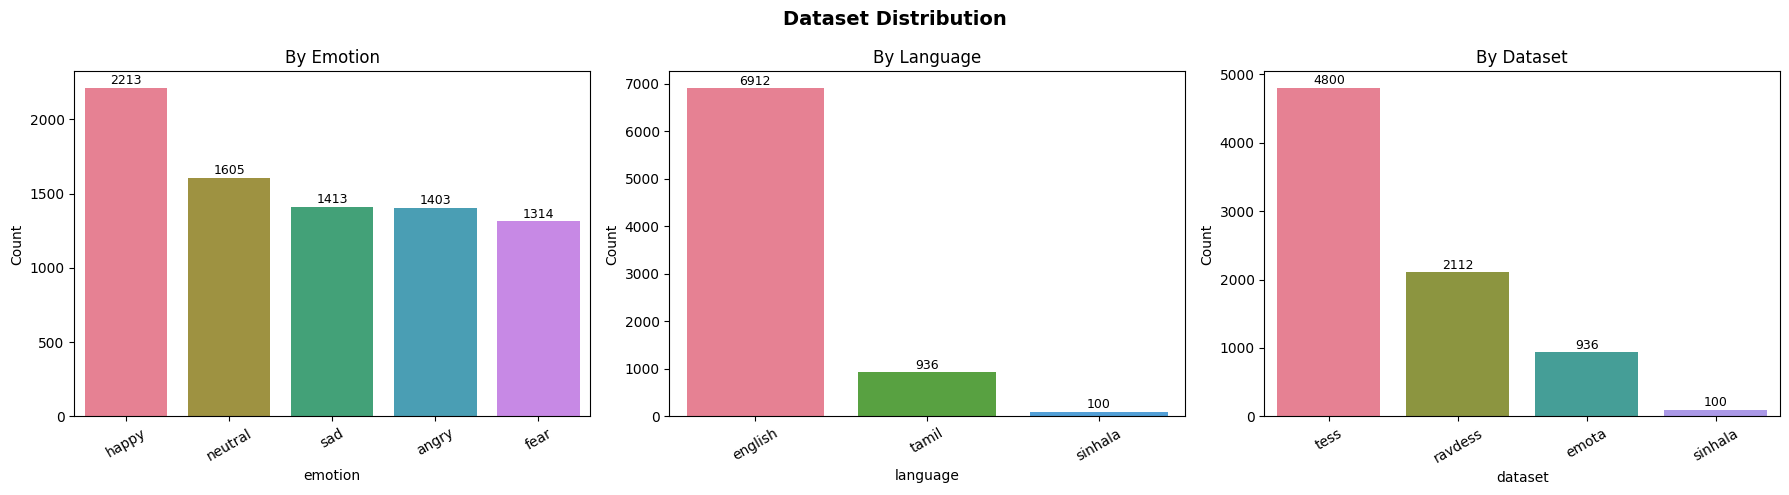

In [6]:
# ─── Dataset Distribution Plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Distribution', fontsize=14, fontweight='bold')

for ax, (group_col, title) in zip(axes, [
    ('emotion',  'By Emotion'),
    ('language', 'By Language'),
    ('dataset',  'By Dataset')
]):
    counts = df_all[group_col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='husl')
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Sinhala Data Augmentation
100 clips → ~700+ clips using pitch shift, time stretch, noise, and reverb.

In [7]:
# ─── Audio Augmentation Pipeline ────────────────────────────────────────────
def load_audio(path, sr=SAMPLE_RATE, max_duration=MAX_DURATION):
    """Load audio, resample to sr, trim/pad to max_duration."""
    audio, _ = librosa.load(path, sr=sr, mono=True)
    max_samples = int(max_duration * sr)
    if len(audio) > max_samples:
        audio = audio[:max_samples]
    else:
        audio = np.pad(audio, (0, max_samples - len(audio)))
    return audio


# Different augmentation pipelines with varying intensity
# We use multiple to maximize diversity from 100 clips
aug_pipelines = [
    # Pipeline 1: Pitch shift up
    A.Compose([
        A.PitchShift(min_semitones=1, max_semitones=4, p=1.0)
    ]),
    # Pipeline 2: Pitch shift down
    A.Compose([
        A.PitchShift(min_semitones=-4, max_semitones=-1, p=1.0)
    ]),
    # Pipeline 3: Time stretch (slow)
    A.Compose([
        A.TimeStretch(min_rate=0.8, max_rate=0.9, p=1.0)
    ]),
    # Pipeline 4: Time stretch (fast)
    A.Compose([
        A.TimeStretch(min_rate=1.1, max_rate=1.2, p=1.0)
    ]),
    # Pipeline 5: Add background noise
    A.Compose([
        A.AddGaussianNoise(min_amplitude=0.002, max_amplitude=0.01, p=1.0)
    ]),
    # Pipeline 6: Pitch + noise
    A.Compose([
        A.PitchShift(min_semitones=-2, max_semitones=2, p=1.0),
        A.AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.008, p=1.0)
    ]),
]


def augment_sinhala(sinhala_records, output_dir, sr=SAMPLE_RATE):
    """Generate augmented copies of all Sinhala clips."""
    aug_records = []
    sinhala_aug_dir = Path(output_dir) / 'sinhala_aug'
    sinhala_aug_dir.mkdir(exist_ok=True)

    for record in tqdm(sinhala_records, desc='Augmenting Sinhala'):
        audio = load_audio(record['path'], sr=sr)
        stem  = Path(record['path']).stem

        # Keep original
        orig_path = sinhala_aug_dir / f'{stem}_orig.wav'
        sf.write(str(orig_path), audio, sr)
        aug_records.append({**record, 'path': str(orig_path), 'augmented': False})

        # Apply each augmentation pipeline
        for idx, pipeline in enumerate(aug_pipelines):
            try:
                aug_audio = pipeline(samples=audio, sample_rate=sr)
                # Re-trim/pad after augmentation
                max_samples = int(MAX_DURATION * sr)
                if len(aug_audio) > max_samples:
                    aug_audio = aug_audio[:max_samples]
                else:
                    aug_audio = np.pad(aug_audio, (0, max_samples - len(aug_audio)))

                aug_path = sinhala_aug_dir / f'{stem}_aug{idx}.wav'
                sf.write(str(aug_path), aug_audio, sr)
                aug_records.append({
                    **record,
                    'path':      str(aug_path),
                    'augmented': True
                })
            except Exception as e:
                print(f'  Augmentation {idx} failed for {stem}: {e}')

    print(f'Sinhala: {len(sinhala_records)} original → {len(aug_records)} total clips')
    return aug_records


# Run augmentation
sinhala_records = [r for r in all_records if r['language'] == 'sinhala']
sinhala_augmented = augment_sinhala(sinhala_records, AUDIO_DIR)

# Rebuild full dataframe with augmented Sinhala
non_sinhala = [r for r in all_records if r['language'] != 'sinhala']
for r in non_sinhala:
    r['augmented'] = False

df_final = pd.DataFrame(non_sinhala + sinhala_augmented)
print(f'\nFinal dataset size: {len(df_final)}')
print(df_final['language'].value_counts())

Augmenting Sinhala: 100%|██████████| 100/100 [00:39<00:00,  2.55it/s]

Sinhala: 100 original → 700 total clips

Final dataset size: 8548
language
english    6912
tamil       936
sinhala     700
Name: count, dtype: int64


## 3. eGeMAPS Feature Extraction
Extracts 88 acoustic features per clip (pitch, energy, MFCCs, shimmer, jitter, HNR).

In [8]:
# ─── eGeMAPS Feature Extractor ───────────────────────────────────────────────
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals,
)
print(f'eGeMAPS feature dimension: {len(smile.feature_names)}')
print('Sample features:', smile.feature_names[:10])

eGeMAPS feature dimension: 88
Sample features: ['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2', 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope']


In [9]:
# ─── Extract Features for All Clips ─────────────────────────────────────────
def extract_gemaps_features(df, smile_extractor, sr=SAMPLE_RATE):
    features_list = []
    valid_indices = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc='Extracting eGeMAPS'):
        try:
            feats = smile_extractor.process_file(row['path'])
            features_list.append(feats.values[0])  # (88,)
            valid_indices.append(idx)
        except Exception as e:
            print(f'  Failed: {row["path"]} — {e}')

    features_array = np.array(features_list, dtype=np.float32)
    df_valid = df.loc[valid_indices].reset_index(drop=True)
    return features_array, df_valid


gemaps_features, df_valid = extract_gemaps_features(df_final, smile)

print(f'\nExtracted features shape: {gemaps_features.shape}')
print(f'Valid clips: {len(df_valid)} / {len(df_final)}')
print(f'NaN count: {np.isnan(gemaps_features).sum()}')

# Replace any NaNs with column means
col_means = np.nanmean(gemaps_features, axis=0)
nan_mask = np.isnan(gemaps_features)
gemaps_features[nan_mask] = np.take(col_means, np.where(nan_mask)[1])
print('NaN handling done')

Extracting eGeMAPS: 100%|██████████| 8548/8548 [24:52<00:00,  5.73it/s]



Extracted features shape: (8548, 88)
Valid clips: 8548 / 8548
NaN count: 0
NaN handling done


In [10]:
# ─── Per-language Feature Normalization ──────────────────────────────────────
# Normalize features within each language group so that
# acoustic range differences between languages don't fool the model

from sklearn.preprocessing import StandardScaler
import joblib

scalers = {}
gemaps_normalized = gemaps_features.copy()

for lang in df_valid['language'].unique():
    lang_mask = (df_valid['language'] == lang).values
    scaler = StandardScaler()
    gemaps_normalized[lang_mask] = scaler.fit_transform(gemaps_features[lang_mask])
    scalers[lang] = scaler
    print(f'  Normalized {lang}: {lang_mask.sum()} clips')

# Save scalers for inference
joblib.dump(scalers, OUTPUT_DIR / 'language_scalers.pkl')
print('Scalers saved')

  Normalized english: 6912 clips
  Normalized tamil: 936 clips
  Normalized sinhala: 700 clips
Scalers saved


## 4. Train/Val/Test Split
Stratified by emotion AND language to ensure all classes appear in every split.

In [11]:
# ─── Stratified Split ────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedShuffleSplit

# Create a combined stratification key: language + emotion
# This ensures each split has proportional coverage of all lang-emotion combos
df_valid['strat_key'] = df_valid['language'] + '_' + df_valid['emotion']
df_valid['label_idx'] = df_valid['emotion'].map(EMOTION_TO_IDX)

# Filter out strat_keys with < 2 samples (can't split them)
key_counts = df_valid['strat_key'].value_counts()
valid_keys = key_counts[key_counts >= 3].index
mask_valid = df_valid['strat_key'].isin(valid_keys)
df_split  = df_valid[mask_valid].reset_index(drop=True)
feats_split = gemaps_normalized[mask_valid.values]

print(f'Clips available for splitting: {len(df_split)}')
print(f'Dropped (too few samples in class): {(~mask_valid).sum()}')

# 80/10/10 split
splitter1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(splitter1.split(feats_split, df_split['strat_key']))

splitter2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(splitter2.split(
    feats_split[temp_idx], df_split.iloc[temp_idx]['strat_key']
))
val_idx  = temp_idx[val_idx]
test_idx = temp_idx[test_idx]

print(f'\nTrain: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')
print('\nTrain language distribution:')
print(df_split.iloc[train_idx]['language'].value_counts())
print('\nVal language distribution:')
print(df_split.iloc[val_idx]['language'].value_counts())

Clips available for splitting: 8548
Dropped (too few samples in class): 0

Train: 6838 | Val: 855 | Test: 855

Train language distribution:
language
english    5529
tamil       749
sinhala     560
Name: count, dtype: int64

Val language distribution:
language
english    691
tamil       94
sinhala     70
Name: count, dtype: int64


In [12]:
# ─── Save All Processed Data ─────────────────────────────────────────────────
save_data = {
    'gemaps_features': feats_split,
    'train_idx':       train_idx,
    'val_idx':         val_idx,
    'test_idx':        test_idx,
    'emotion_labels':  EMOTION_LABELS,
    'emotion_to_idx':  EMOTION_TO_IDX,
    'num_emotions':    NUM_EMOTIONS,
    'sample_rate':     SAMPLE_RATE,
}

np.save(OUTPUT_DIR / 'gemaps_features.npy', feats_split)
np.save(OUTPUT_DIR / 'train_idx.npy', train_idx)
np.save(OUTPUT_DIR / 'val_idx.npy', val_idx)
np.save(OUTPUT_DIR / 'test_idx.npy', test_idx)

df_split.to_csv(OUTPUT_DIR / 'metadata.csv', index=False)

with open(OUTPUT_DIR / 'config.json', 'w') as f:
    json.dump({
        'emotion_labels': EMOTION_LABELS,
        'emotion_to_idx': EMOTION_TO_IDX,
        'num_emotions':   NUM_EMOTIONS,
        'sample_rate':    SAMPLE_RATE,
        'max_duration':   MAX_DURATION,
        'gemaps_dim':     int(feats_split.shape[1]),
    }, f, indent=2)

print('✅ All data saved to:', OUTPUT_DIR)
print('\nFiles saved:')
for f in sorted(OUTPUT_DIR.glob('*')):
    size = f.stat().st_size / 1024
    print(f'  {f.name:<35} {size:.1f} KB')

✅ All data saved to: /kaggle/working/processed

Files saved:
  augmented_audio                     4.0 KB
  config.json                         0.3 KB
  distribution.png                    69.0 KB
  gemaps_features.npy                 2938.5 KB
  language_scalers.pkl                7.2 KB
  metadata.csv                        1409.7 KB
  test_idx.npy                        6.8 KB
  train_idx.npy                       53.5 KB
  val_idx.npy                         6.8 KB


In [13]:
# ─── Final Summary ───────────────────────────────────────────────────────────
print('=' * 55)
print('PREPROCESSING COMPLETE')
print('=' * 55)
print(f'Total clips:          {len(df_split)}')
print(f'  Train:              {len(train_idx)}')
print(f'  Val:                {len(val_idx)}')
print(f'  Test:               {len(test_idx)}')
print(f'eGeMAPS feature dim:  {feats_split.shape[1]}')
print(f'Emotion classes:      {NUM_EMOTIONS} → {EMOTION_LABELS}')
print(f'Languages:            {df_split["language"].unique().tolist()}')
print('\n➡️  Run Notebook 2: 02_model_training.ipynb')

PREPROCESSING COMPLETE
Total clips:          8548
  Train:              6838
  Val:                855
  Test:               855
eGeMAPS feature dim:  88
Emotion classes:      5 → ['neutral', 'happy', 'sad', 'angry', 'fear']
Languages:            ['english', 'tamil', 'sinhala']

➡️  Run Notebook 2: 02_model_training.ipynb
